## Resultados Generador Agrawal

In [1]:
from src.data.agrawal_drift_generator import main
main()

/home/eduardo/tfg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generated 20000 samples in 40 blocks at: datasets/agrawal_abrupt.csv
Dataset generado: datasets/agrawal_abrupt.csv (20000 filas, 40 bloques)
Dataset generado: datasets/agrawal_gradual.csv (20000 filas, 40 bloques)
Generated 20000 samples in 40 blocks at: datasets/agrawal_recurrent.csv
Dataset generado: datasets/agrawal_recurrent.csv (20000 filas, 40 bloques)
Generación completada y validada para abrupt, gradual y recurrent.


In [2]:
from src.run_passive_ensembles import run_experiment

res_recurrent = run_experiment("datasets/agrawal_recurrent.csv")
res_abrupt = run_experiment("datasets/agrawal_abrupt.csv")
res_gradual = run_experiment("datasets/agrawal_gradual.csv")


=== Results for agrawal_recurrent ===

SEA
  Runs               : 1
  Accuracy mean      : 0.6391 ± 0.0000
  Accuracy min       : 0.3660 ± 0.0000
  Recovery mean      : 3.6
  Kappa mean         : 0.3487 ± 0.0000
  Diversity mean     : 0.3249 ± 0.0000
  Time mean (s)      : 14.4689 ± 0.0000
  Num drops          : 5 ± 0.00

AUE2
  Runs               : 1
  Accuracy mean      : 0.6814 ± 0.0000
  Accuracy min       : 0.3700 ± 0.0000
  Recovery mean      : 2.8333333333333335
  Kappa mean         : 0.3958 ± 0.0000
  Diversity mean     : 0.3247 ± 0.0000
  Time mean (s)      : 18.8795 ± 0.0000
  Num drops          : 6 ± 0.00

WAE
  Runs               : 1
  Accuracy mean      : 0.7058 ± 0.0000
  Accuracy min       : 0.3800 ± 0.0000
  Recovery mean      : 2.142857142857143
  Kappa mean         : 0.4482 ± 0.0000
  Diversity mean     : 0.3349 ± 0.0000
  Time mean (s)      : 22.6133 ± 0.0000
  Num drops          : 7 ± 0.00

Learn++NSE
  Runs               : 1
  Accuracy mean      : 0.7188 ± 0.0000


In [3]:
import pandas as pd

def results_to_df(results_dict):
    rows = []

    for model, m in results_dict.items():
        rows.append({
            "Model": model,
            "Accuracy": m["accuracy_mean_mean"],
            "Min Accuracy": m["accuracy_min_mean"],
            "Kappa": m["kappa_mean_mean"],
            "Diversity": m["diversity_mean_mean"],
            "Time (s)": m["time_mean"],
            "Recovery": m["recovery_mean_mean"],
            "Num Drops": m["num_drops_mean"],
        })

    df = pd.DataFrame(rows)
    return df.sort_values(by="Accuracy", ascending=False).round(4)

In [4]:
df_recurrent = results_to_df(res_recurrent)
df_abrupt    = results_to_df(res_abrupt)
df_gradual   = results_to_df(res_gradual)

In [5]:
print("=== Gradual Drift ===")
df_gradual.style.background_gradient(cmap="Oranges")

=== Gradual Drift ===


/home/eduardo/tfg/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/eduardo/tfg/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.730900,0.580000,0.601500,0.205600,11.781900,nan,0.000000
2,WAE,0.722900,0.560000,0.588000,0.222900,20.242800,nan,0.000000
1,AUE2,0.711200,0.448000,0.587900,0.209700,18.099200,nan,0.000000
0,SEA,0.708600,0.448000,0.586200,0.208800,13.867100,nan,0.000000


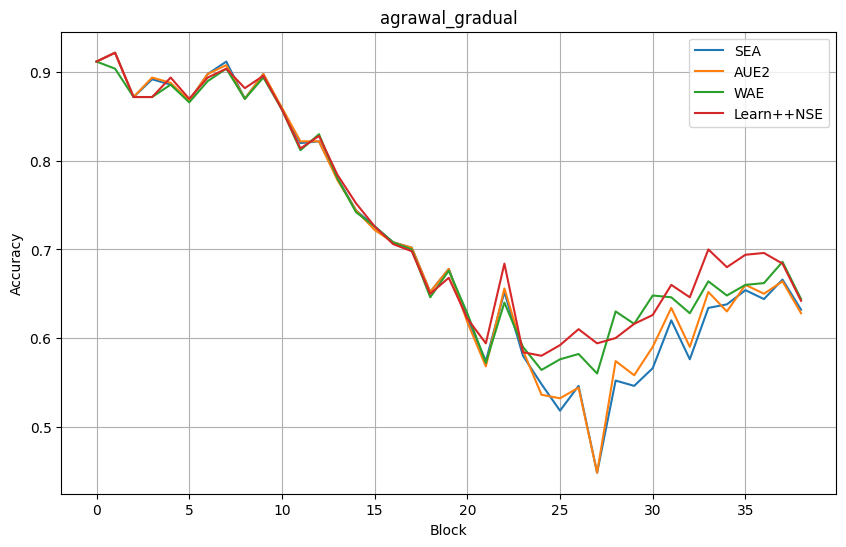

In [6]:
from IPython.display import Image, display
display(Image(filename="plots/agrawal_gradual.png"))

In [7]:
print("=== Recurrent Drift ===")
df_recurrent.style.background_gradient(cmap="Greens")

=== Recurrent Drift ===


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.718800,0.372000,0.476900,0.337400,13.750700,2.166700,6.000000
2,WAE,0.705800,0.380000,0.448200,0.334900,22.613300,2.142900,7.000000
1,AUE2,0.681400,0.370000,0.395800,0.324700,18.879500,2.833300,6.000000
0,SEA,0.639100,0.366000,0.348700,0.324900,14.468900,3.600000,5.000000


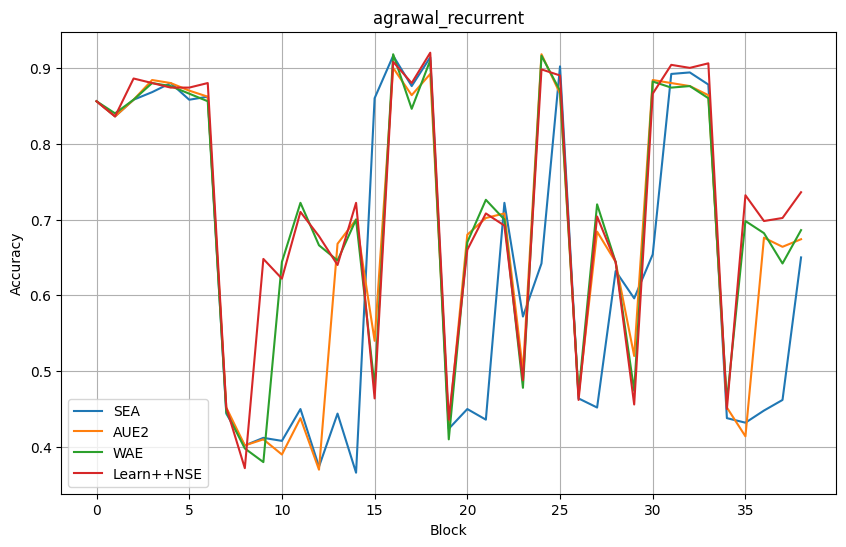

In [8]:

display(Image(filename="plots/agrawal_recurrent.png"))

In [10]:
print("=== Abrupt Drift ===")
df_abrupt.style.background_gradient(cmap="Blues")

=== Abrupt Drift ===


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.764600,0.372000,0.652900,0.210400,11.483900,6.000000,1.000000
2,WAE,0.746200,0.404000,0.630000,0.221500,19.312500,7.000000,1.000000
1,AUE2,0.730900,0.390000,0.621300,0.211300,17.825900,9.000000,1.000000
0,SEA,0.712700,0.392000,0.605900,0.210700,15.565400,11.000000,1.000000


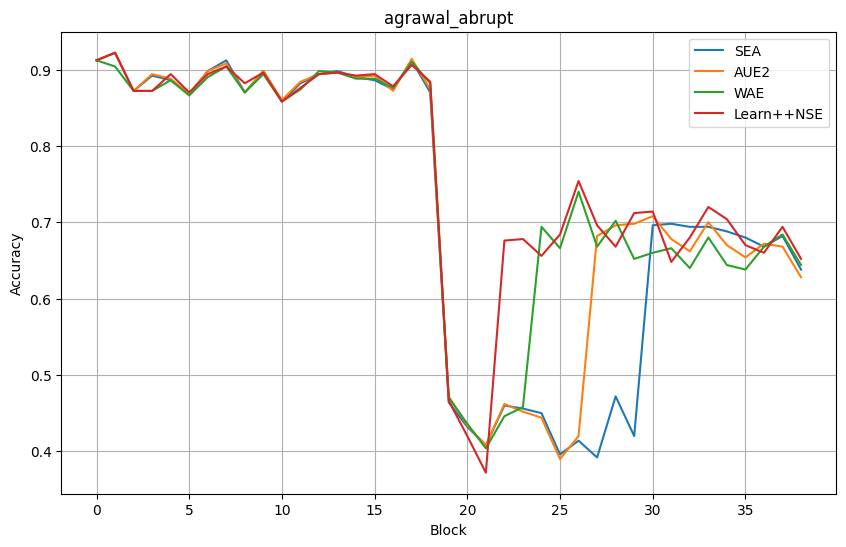

In [11]:

display(Image(filename="plots/agrawal_abrupt.png"))

In [12]:
from src.optimization.dynamic_config import DynamicMOEAConfig
from src.optimization.dynamic_runner import run_dynamic_moea_experiment
config2 =DynamicMOEAConfig(
    dataset_path="datasets/agrawal_abrupt.csv",
    window_size=10,

    pop_size=8,
    n_gen=3,

    max_size=20,
    baseline_max_size=20,

    initial_a=0.5,
    initial_b=5.0,
    baseline_a=0.5,
    baseline_b=5.0,

    verbose=True,
)

results2 = run_dynamic_moea_experiment(config2)

Dataset: datasets/agrawal_abrupt.csv
Bloques: 40
Reoptimización: pasiva
Criterio: se ejecuta en cada bloque con ventana completa
Detector de drift: no se usa
Ventana fija: 10 bloques
max_size fijo del MOEA pasivo: 20
NSGA-II: pop_size=8, n_gen=3
Objetivos MOEA: maximizar recent_accuracy y diversity; minimizar tiempo de ejecución
Evaluación de candidatos: desde checkpoints del ensemble real anteriores a la ventana fija.
Reoptimización pasiva tras bloque 9: a=0.8512, b=14.8659, recent_accuracy=0.8920, diversity=0.0856, elapsed=1.080373s
Reoptimización pasiva tras bloque 10: a=1.7968, b=8.0524, recent_accuracy=0.8924, diversity=0.0873, elapsed=1.315443s
Reoptimización pasiva tras bloque 11: a=0.5113, b=11.2945, recent_accuracy=0.8868, diversity=0.0958, elapsed=1.481207s
Reoptimización pasiva tras bloque 12: a=1.9081, b=14.1453, recent_accuracy=0.8822, diversity=0.0998, elapsed=1.698270s
Reoptimización pasiva tras bloque 13: a=1.0362, b=11.5451, recent_accuracy=0.8844, diversity=0.1024, el

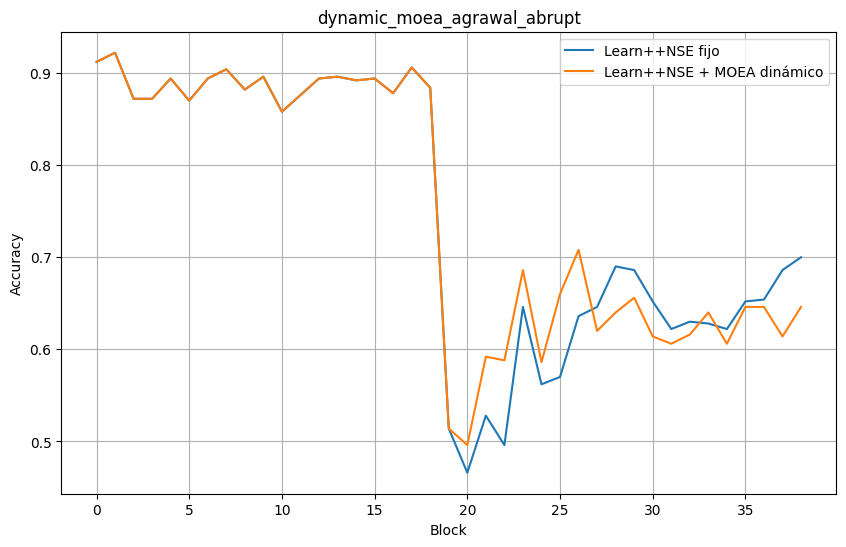

In [14]:
from IPython.display import Image, display
display(Image(filename="plots/dynamic_moea_agrawal_abrupt.png"))